# Conjuntos de entrenamiento y prueba (función train, test y split)

En la práctica es bien sabido que la cantidad de datos que se tiene es finita y con ellos deben calcularse los parámetros óptimos del modelo al igual que los hiperparámetros del mismo. 

## Generación de datos. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

In [2]:
#
# Función a aproximar
# (Proceso geneador de datos)
#
def f(x):
    return 2 * np.abs(np.sin(x * np.pi / 4 + 0.75)) / (1 + 0.1 * x)


#
# Datos reales.
# (No disponibles en la realidad)
# es para ver el comportamiento real 
# y su comparación con los modelos. 
x_real = np.linspace(0, 10, 100)
X_real = x_real[:, np.newaxis]
y_real = f(x_real)

In [3]:
#
# Muestra de datos.
# (Información disponible en la realidad)
#

# establecer semilla
rng = np.random.default_rng(12345)

x_sample = x_real.copy() # copia de los datos reales
rng.shuffle(x_sample) # los revolvemos
x_sample = x_sample[:25] # tomamos solo una muestra de 25
x_sample = np.sort(x_sample) # los ordenamos

y_sample = f(x_sample) # creamos los valores de la
# varaible objetivo Y

# volver un vector con filas y columnas
X_sample = x_sample[:, np.newaxis]

## Muestras en entrenamiento y prueba

* La generalización del modelo debe estimarse a partir de los datos disponibles.

* Los datos disponibles se dividen en dos conjuntos: uno para ajuste de parámetros del modelo (entrenamiento/train) y otro para medir la generalización o pronósticar para datos desconocidos (prueba/test).

* La totalidad de la información es usada para determinar el grado óptimo del polinómio y sus coeficientes.

* Esta aproximación es usada en TensorFlow

In [4]:
# se importa la libreria para usar el método de train_test_split
from sklearn.model_selection import train_test_split

#
# Se usan 20 ejemplos para entrenamiento del modelo y los 5 restantes
# para medir la generalización.
#
X_train, X_test, y_train_true, y_test_true = train_test_split(
    # --------------------------------------------------------------------------
    # Los primeros train_size ejemplos son asignados al conjunto de
    # entrenamiento. Del resto de la muestra, los primeros test_size son
    # asignados a la muestra de prueba
    X_sample,
    y_sample,
    # --------------------------------------------------------------------------
    # Tamaño de la muestra de prueba.
    # int: indica la cantidad de muestras
    # float: indica el porcentaje y debe estar entre 0.0 y 1.0
    test_size=5,
    # --------------------------------------------------------------------------
    # Tamaño de la muestra de entrenamiento.
    # int: indica la cantidad de muestras
    # float: indica el porcentaje y debe estar entre 0.0 y 1.0
    train_size=None,
    # --------------------------------------------------------------------------
    # Semilla del generador aleatorio
    random_state=12345,
    # --------------------------------------------------------------------------
    # Mezcla los ejemplos antes de hacer la partición
    shuffle=True,
)

## Evaluación para la muestra de datos disponible

In [ ]:
import pandas as pd
from sklearn.metrics import mean_squared_error

# lista de los posbiles grados 
# del polinomio para el modelo de regresión.
degrees = list(range(1, 21))

# listas par guardar el mse de los distintos
# modelos en los casos de train y test
mse_train = []
mse_test = []

for i_degree, degree in enumerate(degrees):

    # Creación del pipeline
    model = make_pipeline(

        # crear polinomio de grado 
        # dado a partir de las variable.
        # si hay más de una variable
        # tiene en cuensta las interacciones. 
        PolynomialFeatures(degree, include_bias=False),

        # Aplicar MinMaxScaler a los datos
        # que viene a ser la normalización
        # para que los datos estén 
        # en una escala de 0 y 1. Le pasa esto
        # a toda las columnas. 
        MinMaxScaler(),

        # instancia de regresión 
        # lineal par que este modelo 
        # sea el que se ajuste. 
        LinearRegression(),
    )

    # ajustamos el modelo 
    # con todos los pasos
    model.fit(X_train, y_train_true)

    # generar predicciones para datos de train
    y_train_pred = model.predict(X_train)

    # generar predicciones para datos de test
    y_test_pred = model.predict(X_test)

    # generar MSE y agregarlos a la lista.  
    mse_train.append(mean_squared_error(y_train_true, y_train_pred))
    mse_test.append(mean_squared_error(y_test_true, y_test_pred))


# creación de un data frame para ver las 
# comparaciones. Ordenar por el valor
# más pequeño del MSe de test
df = pd.DataFrame(
    {
        "Degree": degrees,
        "MSE train": mse_train,
        "MSE test": mse_test,
    }
).sort_values("MSE test", ascending=True)

# en este caso se esta usando la muestra
# de training y la muestra de test
# para encontrar los hiperparámetros óptimos
# sin embargo, el modelo no se esta gurdardando.
# Esto es solo para mejorar nuestro lo más que
# podamos, luego debemos re-entrenarlo 
# solamente con la muestra de train. 

df

,Degree,MSE train,MSE test
7,8,0.004806,0.007449
12,13,0.003777,0.007540
13,14,0.003662,0.007548
11,12,0.003956,0.007707
16,17,0.003633,0.007748
15,16,0.003632,0.007796
14,15,0.003622,0.007804
17,18,0.003630,0.007811
18,19,0.003632,0.007968
10,11,0.004181,0.008023


In [7]:
#
# Grado óptimo del polinomio
#
df.Degree.iloc[0]

np.int64(8)

## Pronóstico con el mejor modelo encontrado

In [ ]:
optimal_degree = df.Degree.iloc[0]

# hacer el pipeline para el modelo 
model = make_pipeline(
    PolynomialFeatures(optimal_degree, include_bias=False),
    MinMaxScaler(),
    LinearRegression(),
)

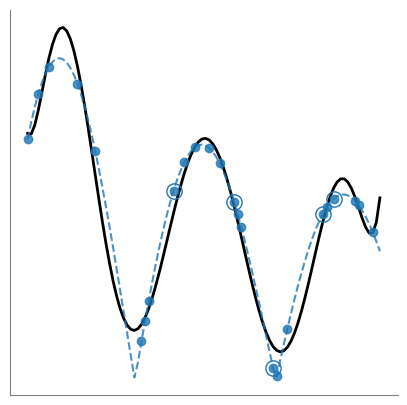

In [ ]:
#
# Opción 1: Modelo óptimo entrenado solo con la muestra de
#   entrenamiento.
#


#ajuste
model.fit(X_train, y_train_true)

#predicciones
y_pred = model.predict(X_real)

#figura de 5x5
plt.figure(figsize=(5, 5))

# curva de los valores de X reales
# contra los valroes de Y reales.
# lineas dis-continuas
plt.plot(x_real, y_real, "--", color="tab:blue", alpha=0.8, zorder=10)

# curva de los valroes de X se la muestra
# contra los valores de Y de la muestra
# datos en puntos
plt.plot(x_sample, y_sample, "o", color="tab:blue", alpha=0.8, zorder=10)

# mostrar como se comportan los valores 
# de test, valore encerrados en círculos
plt.plot(
    X_test,
    y_test_true,
    "o",
    color="tab:blue",
    alpha=1.0,
    zorder=10,
    markersize=11,
    fillstyle="none",
)

# mostrar valores reales de X contra
# lo que dan los valores pronosticados
# por el modelo que ajustamos
plt.plot(
    x_real,
    y_pred,
    color="black",
    linewidth=2,
)

plt.xticks([], [])
plt.yticks([], [])

plt.gca().spines["left"].set_color("gray")
plt.gca().spines["bottom"].set_color("gray")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.show()

Es claro que hay un muy buen ajuste para los datos de entrenamiento pero falla en la generalización del final, sin embargo, esto no es posible saberlo en el mundo real. 

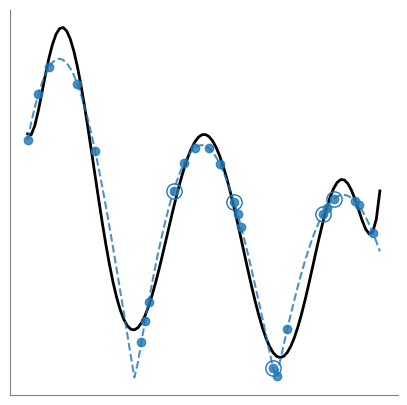

In [10]:
#
# Opción 2: Modelo óptimo entrenado con la totalidad de
#   la muestra.
#
model.fit(X_sample, y_sample)

y_pred = model.predict(X_real)

plt.figure(figsize=(5, 5))
plt.plot(x_real, y_real, "--", color="tab:blue", alpha=0.8, zorder=10)
plt.plot(x_sample, y_sample, "o", color="tab:blue", alpha=0.8, zorder=10)
plt.plot(
    X_test,
    y_test_true,
    "o",
    color="tab:blue",
    alpha=1.0,
    zorder=10,
    markersize=11,
    fillstyle="none",
)

plt.plot(
    x_real,
    y_pred,
    color="black",
    linewidth=2,
)

plt.xticks([], [])
plt.yticks([], [])

plt.gca().spines["left"].set_color("gray")
plt.gca().spines["bottom"].set_color("gray")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.show()

Dicen que luego de haber hallado los hiperparámetros lo mejor es entrenar los modelos con la totalidad de los datos, olvidarnos de las particiones. Pues se supone ya se tiene correctamente el modelo deseado. 

```skelarn.model_selection.tren_test_split(
arrays,
test_size=None,
train_size=None,
random_state=None,
shuffle=True,
stratify=None
)```

Lo que hace esta función es particionar arrays o matrices en valores aleatorios en subconjuntos de train y test.

**array** : Es cualquier estructura de datos que puede ser una array com un data frame, pero para los data frame de pandas deben tener la dimensión 1. 

**test_size** = entero o flotante, el flotante entre 0 y 1 y representa la propoción del dataset para el conjunto de prueba. Si es un entero entonces será el número exacto de elementos para el conjunto de prueba. Por de defecto es 0.25, es decir, 25% para test y 75% para train. 

**train_size** = entero o flotante, es lo mismo que lo anterior pero si no se pone nada pues se toma como el complemente del test_size. 

**random_state** = es la semilla para poder reproducir la reproducibilidad. Por defecto no hay. 

**shuffle**: Es para indicar si se deben barajar los datos ante de hacer las particiones, lo cual es recomendable siempre en problemas de regresión. Si es False entonces stratify también debe ser False. 

**stratify**: array de n-muestras, se usa para los casos de clasificación en los que se debe tener
un muestreo por estrato para que haya sufieciente de cada categoría en las respectivas particiones. Por defecto es False. 

Es importante mencionar que esta función retorna 4 conjuntos de datos, X_train, X_test, y_train_true, y_test_true en ese orden respectivo. 

In [ ]:
# ejemplo
import numpy as np
from sklearn.model_selection import train_test_split


X, y = np.arange(10).reshape((5, 2)), range(5)
print(X)
list(y)

[0, 1, 2, 3, 4]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

# partición del 0.33 de los datos para test
# y el resto para entrenamiento. Usando
# la semilla de 42
X_train
y_train
X_test
y_test

[1, 4]

In [ ]:
train_test_split(y, shuffle=False)
#notese que al hacer shuffle = False
# se hace simplemente las particiones 
# de los datos sin mesclalos y 
# directamente con test_size = 0.25

[[0, 1, 2], [3, 4]]

Nota: uso de la función PolynomialFeatures: 

Es una herramienta de preprocesamiento de scikit-learn que genera nuevas características elevando las existentes a una potencia o combinándolas entre sí

¿Para qué sirve? 

Capturar relaciones no lineales: Permite que un modelo lineal aprenda patrones curvos.

Crear términos de interacción: Multiplica variables para ver si juntas tienen un efecto distinto.

Mejorar el rendimiento: Ayuda a modelos simples a resolver problemas complejos.

Parámetros principales

degree: Grado máximo del polinomio (por defecto es 2).

interaction_only: Si es True, solo crea productos entre variables distintas, sin elevarlas al cuadrado.

include_bias: Si es True (por defecto), añade una columna de unos para el intercepto.

Lo que hace es expandir tu matriz de datos original agregando nuevas columnas basadas en las potencias y en las combinaciones de las variables existentes.

Con una sola variable (\[x\]): Eleva esa variable a las potencias indicadas por el grado (degree). Si eliges grado 3, creará las columnas: \[x\], \[x^{2}\] y \[x^{3}\].

Con múltiples variables (\(x_1, x_2\)): Además de elevar cada una al cuadrado o al cubo, calcula todas las combinaciones multiplicadas entre ellas (las interacciones). 

Nota: MinMaxScaler

Este método es un método de transformación de variables. Que permite que las variables queden en una escala entre 0 y 1 ( o -1 y 1). Es un método que Preserva la distribución original de los datos sin distorsionarla y asegura que todos los valores queden acotados en el mismo rango (ideal para redes neuronales o algoritmos basados en distancias como KNN). Lo malo es que   Es muy sensible a la presencia de valores atípicos (outliers), ya que un valor extremo muy distante comprimirá el rango del resto de los datos.